In [1]:
from ceridwen.dust import Dust
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Matplotlib Setup: LaTeX Consistency
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
colors = ['darkviolet', 'dodgerblue', 'forestgreen', 'orange', 'coral', 'mediumvioletred', 'teal']
sns.set_palette(colors)

wave = pd.read_csv("/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/spectra.csv")['wave'].values

In [2]:
dust = Dust(laws=['smc', 'smc'], diffuse_law=None)

fit_params = dust.get_default_fit_params()

print(fit_params)


[dust setup] Law 'smc' is used multiple times. Registered as 'smc1'.
             Use parameters: tau_smc1
             Parameters like tau_smc will be ignored, unless in the diffuse_params dict.
[dust setup] Law 'smc' is used multiple times. Registered as 'smc2'.
             Use parameters: tau_smc2
             Parameters like tau_smc will be ignored, unless in the diffuse_params dict.
{'tau_smc1': 1.0, 'tau_smc2': 1.0}


In [3]:
fit_params = {'tau_smc1': 5.0, 'tau_smc2': 0.2, 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}
attn_curves = dust.compute_attenuation(wave, fit_params=fit_params)
len(attn_curves)

2

In [4]:
from sedpy_jax.attenuation_dust import smc

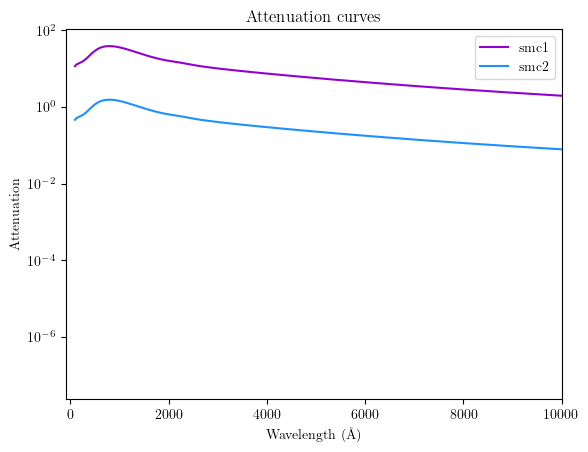

In [5]:
#plt.plot(wave, smc(wave, fit_params['tau_smc1']), label="smc1 sedpy")
#plt.plot(wave, smc(wave, fit_params['tau_smc2']), label="smc2 sedpy")
plt.plot(wave, attn_curves[0], label="smc1")
plt.plot(wave, attn_curves[1], label="smc2")

plt.legend()
plt.xlabel("Wavelength (\AA)")
plt.ylabel("Attenuation")
plt.title("Attenuation curves")
plt.xlim(-100, 10000)
plt.yscale("log")

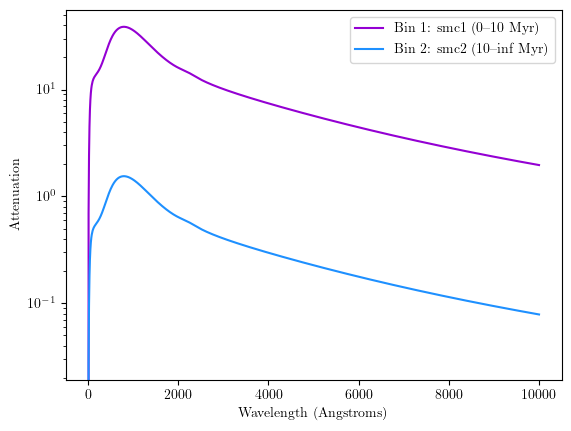

In [12]:
fig, ax = dust.display(fit_params=fit_params)


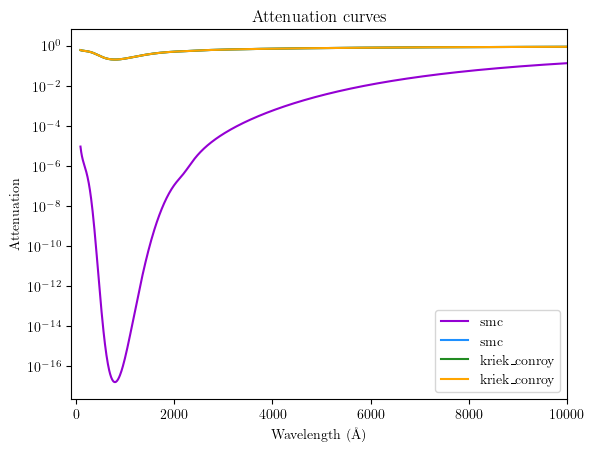

In [13]:
plt.plot(wave, jnp.exp(-attn_curves[0]), label="smc")
#plt.plot(wave, smc(wave, tau_smc=1), label="smc sedpy")
plt.plot(wave, jnp.exp(-attn_curves[1]), label="smc")
plt.plot(wave, jnp.exp(-attn_curves[2]), label="kriek_conroy")
plt.plot(wave, jnp.exp(-attn_curves[3]), label="kriek_conroy")
plt.legend()
plt.xlabel("Wavelength (\AA)")
plt.ylabel("Attenuation")
plt.title("Attenuation curves")
plt.xlim(-100, 10000)
plt.yscale("log")


In [8]:
from sedpy_jax.attenuation_dust import smc, kriek_conroy, ATTENUATION_LAWS

In [9]:
from pprint import pprint

pprint(ATTENUATION_LAWS)

{'calzetti': {'defaults': {'R_v_cal00': 4.05, 'tau_cal00': 1.0},
              'doc': 'Empirical attenuation curve for local starbursts '
                     '(Calzetti et al. 2000).',
              'func': <function calzetti at 0x10d0cad40>,
              'params': {'R_v_cal00': 'Not used (shape is fixed)',
                         'tau_cal00': 'V-band optical depth'}},
 'cardelli': {'defaults': {'R_v_card': 3.1, 'tau_card': 1.0},
              'doc': 'Extinction law from Cardelli, Clayton & Mathis (1989), '
                     'used widely in the Milky Way.',
              'func': <function cardelli at 0x10d0cb010>,
              'params': {'R_v_card': 'Rv, the total-to-selective extinction '
                                     'ratio',
                         'tau_card': 'Optical depth at 5500 \\AA'}},
 'chevallard': {'defaults': {'tau_chev': 1.0},
                'doc': 'Attenuation curve from Chevallard et al. (2013), '
                       'including birth cloud and ISM com